In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

In [45]:
df1803 = pd.read_csv('../data/labeled/partial_plug/1803.csv')
df2906_1 = pd.read_csv('../data/labeled/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/labeled/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/labeled/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/labeled/no_plug/0404.csv')
df0712 = pd.read_csv('../data/labeled/no_plug/0712.csv')
df1103 = pd.read_csv('../data/labeled/partial_plug/1103.csv')
df2503 = pd.read_csv('../data/labeled/partial_plug/2503.csv')
df1703 = pd.read_csv('../data/labeled/no_plug/1703.csv')

df0709 = pd.read_csv('../data/labeled/plug/0709.csv')
df2106_2 = pd.read_csv('../data/labeled/plug/2106-2.csv')
df2108_1 = pd.read_csv('../data/labeled/plug/2108-1.csv')
df2108_2 = pd.read_csv('../data/labeled/plug/2108-2.csv')
df2906_2 = pd.read_csv('../data/labeled/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/labeled/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/labeled/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/labeled/plug/3006-3.csv')
df0612_2 = pd.read_csv('../data/labeled/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/labeled/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/labeled/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/labeled/plug/0707-2.csv')
df0707_4 = pd.read_csv('../data/labeled/plug/0707-4.csv')
df1112 = pd.read_csv('../data/labeled/plug/1112.csv')
df1310_2 = pd.read_csv('../data/labeled/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/labeled/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/labeled/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/labeled/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/labeled/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/labeled/plug/1407-4.csv')
df1503 = pd.read_csv('../data/labeled/plug/1503.csv')
df1811 = pd.read_csv('../data/labeled/plug/1811.csv')
df2701 = pd.read_csv('../data/labeled/plug/2701.csv')
df1003 = pd.read_csv('../data/labeled/plug/1003.csv')

In [46]:
raw_no_p_dfs = [df1703, df2906_1, df3006_1, df3006_2, df0404, df0712]

no_p_names = ['1703', '2906-1', '3006-1', '3006-2', '0404', '0712']

raw_p_dfs = [df1003, df0709, df2106_2, df2108_1, df2108_2, df2906_2, df2906_3, df2906_4, 
            df3006_3, df0612_2, df0612_3, df0707_1, df0707_2, df0707_4, df1112, 
            df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701, df1803, df1103, df2503]

p_names = ['1003', '0709', '2106-2', '2108-1', '2108-2', '2906-2', '2906-3', '2906-4',
           '3006-3', '0612-2', '0612-3', '0707-1', '0707-2', '0707-4', '1112',
           '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701', '1803', '1103', '2503']

In [47]:
for df in raw_no_p_dfs:
    if 'elapsed_runtime_m' in df.columns and 'elapsed_runtime_s' in df.columns and 'reading_interval_s' in df.columns:
        df.drop(columns = ['elapsed_runtime_m', 'elapsed_runtime_s', 'reading_interval_s'], inplace=True)
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

for df in raw_p_dfs:
    if 'elapsed_runtime_m' in df.columns and 'elapsed_runtime_s' in df.columns and 'reading_interval_s' in df.columns:
        df.drop(columns = ['elapsed_runtime_m', 'elapsed_runtime_s', 'reading_interval_s'], inplace=True)
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
  

In [48]:
df1003.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257430 entries, 0 to 257429
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Time                          257430 non-null  datetime64[ns]
 1   Temperature TS inlet (Mean)   257430 non-null  float64       
 2   Temperature TS outlet (Mean)  257430 non-null  float64       
 3   Tank temperature (Mean)       257430 non-null  float64       
 4   Bypass temperature (Mean)     257430 non-null  float64       
 5   Pump outlet pressure (Mean)   257430 non-null  float64       
 6   TS inlet pressure (Mean)      257430 non-null  float64       
 7   TS outlet pressure (Mean)     257430 non-null  float64       
 8   Differential pressure (Mean)  257430 non-null  float64       
 9   Pump to inlet DP              257430 non-null  float64       
 10  Total system DP               257430 non-null  float64       
 11  Flow rate (Me

In [49]:
master_column_order = [
    'Time',
    'Flow rate (Mean)',
    'TS outlet pressure (Mean)',
    'TS inlet pressure (Mean)',
    'Pump outlet pressure (Mean)',
    'Temperature TS outlet (Mean)',
    'Tank temperature (Mean)',
    'Temperature TS inlet (Mean)',
    'Bypass temperature (Mean)',
    'Differential pressure (Mean)',
    'Pump to inlet DP',
    'Total system DP',
    #'Relative_DP',
    #'Pressure_Ratio',
    #'Relative_Ratio_Dev',
    'Plug_Label'
]

In [50]:
ordered_n_dfs = []
ordered_p_dfs = []

for df in raw_no_p_dfs:
    df_reordered = df[master_column_order].copy()
    ordered_n_dfs.append(df_reordered)
for df in raw_p_dfs:
    df_reordered = df[master_column_order].copy()
    ordered_p_dfs.append(df_reordered)

In [51]:
def standardize_time_and_resample(df, interval='1s'):
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S.%f')
    df = df.set_index('Time').sort_index()

    resampled_df = df.resample(interval).mean().interpolate(method='linear')
    
    return resampled_df.reset_index()

full_standardized_n_dfs = [standardize_time_and_resample(df) for df in ordered_n_dfs]
full_standardized_p_dfs = [standardize_time_and_resample(df) for df in ordered_p_dfs]

In [52]:
standardized_p_dfs = []
standardized_n_dfs = []
standardized_p_names = []
standardized_n_names = []
for i, df in enumerate(full_standardized_p_dfs):
    if len(df) > 300:
        standardized_p_dfs.append(df)
        standardized_p_names.append(p_names[i])

for i, df in enumerate(full_standardized_n_dfs):
    if len(df) > 300:
        standardized_n_dfs.append(df)
        standardized_n_names.append(no_p_names[i])


In [53]:
def extract_features(df_list):
    all_features = []
    processed_dfs = []
    
    for df in df_list:
        temp = df.copy()
       
        base_tot_dp = temp['Total system DP'].iloc[:30].median()
        temp['rel_tot_dp_change'] = temp['Total system DP'] / base_tot_dp

        base_ts_dp = temp['Differential pressure (Mean)'].iloc[:30].median()
        temp['rel_ts_dp_change'] = temp['Differential pressure (Mean)'] / base_ts_dp
        base_p_ts_dp = temp['Pump to inlet DP'].iloc[:30].median()
        temp['rel_p_ts_dp_change'] = temp['Pump to inlet DP'] / base_p_ts_dp
        
        temp = temp.dropna()
        processed_dfs.append(temp)

        features = ['rel_p_ts_dp_change', 'rel_ts_dp_change', 'rel_tot_dp_change']
        all_features.append(temp[features])
        
    return pd.concat(all_features), processed_dfs

In [54]:
X_train_raw, clean_processed = extract_features(standardized_n_dfs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

In [120]:
model = IsolationForest(
    n_estimators=300, 
    contamination=0.015,
    random_state=42
)
model.fit(X_train_scaled)

IsolationForest(contamination=0.015, n_estimators=300, random_state=42)

In [121]:
_, plug_processed = extract_features(standardized_p_dfs)

scored_plug_dfs = []
features_list = ['rel_p_ts_dp_change', 'rel_ts_dp_change', 'rel_tot_dp_change']

for df in plug_processed:
    temp = df.copy()
    X_test = scaler.transform(temp[features_list])
    
    temp['anomaly_score'] = model.decision_function(X_test)
    
    temp['smooth_score'] = temp['anomaly_score'].rolling(window=3).mean()
    scored_plug_dfs.append(temp)

In [122]:
scored_clean_dfs = []
for df in clean_processed:
    temp = df.copy()
    X_test = scaler.transform(temp[features_list])
    temp['anomaly_score'] = model.decision_function(X_test)
    temp['smooth_score'] = temp['anomaly_score'].rolling(window=4).mean()
    scored_clean_dfs.append(temp)

min_n = min([df['smooth_score'].dropna().min() for df in scored_clean_dfs])
min_p = min([df['smooth_score'].dropna().min() for df in scored_plug_dfs])

print(f"Deepest Anomaly in Normal Runs: {min_n:.4f}")
print(f"Deepest Anomaly in Plug Runs:   {min_p:.4f}")

Deepest Anomaly in Normal Runs: -0.0267
Deepest Anomaly in Plug Runs:   -0.1111


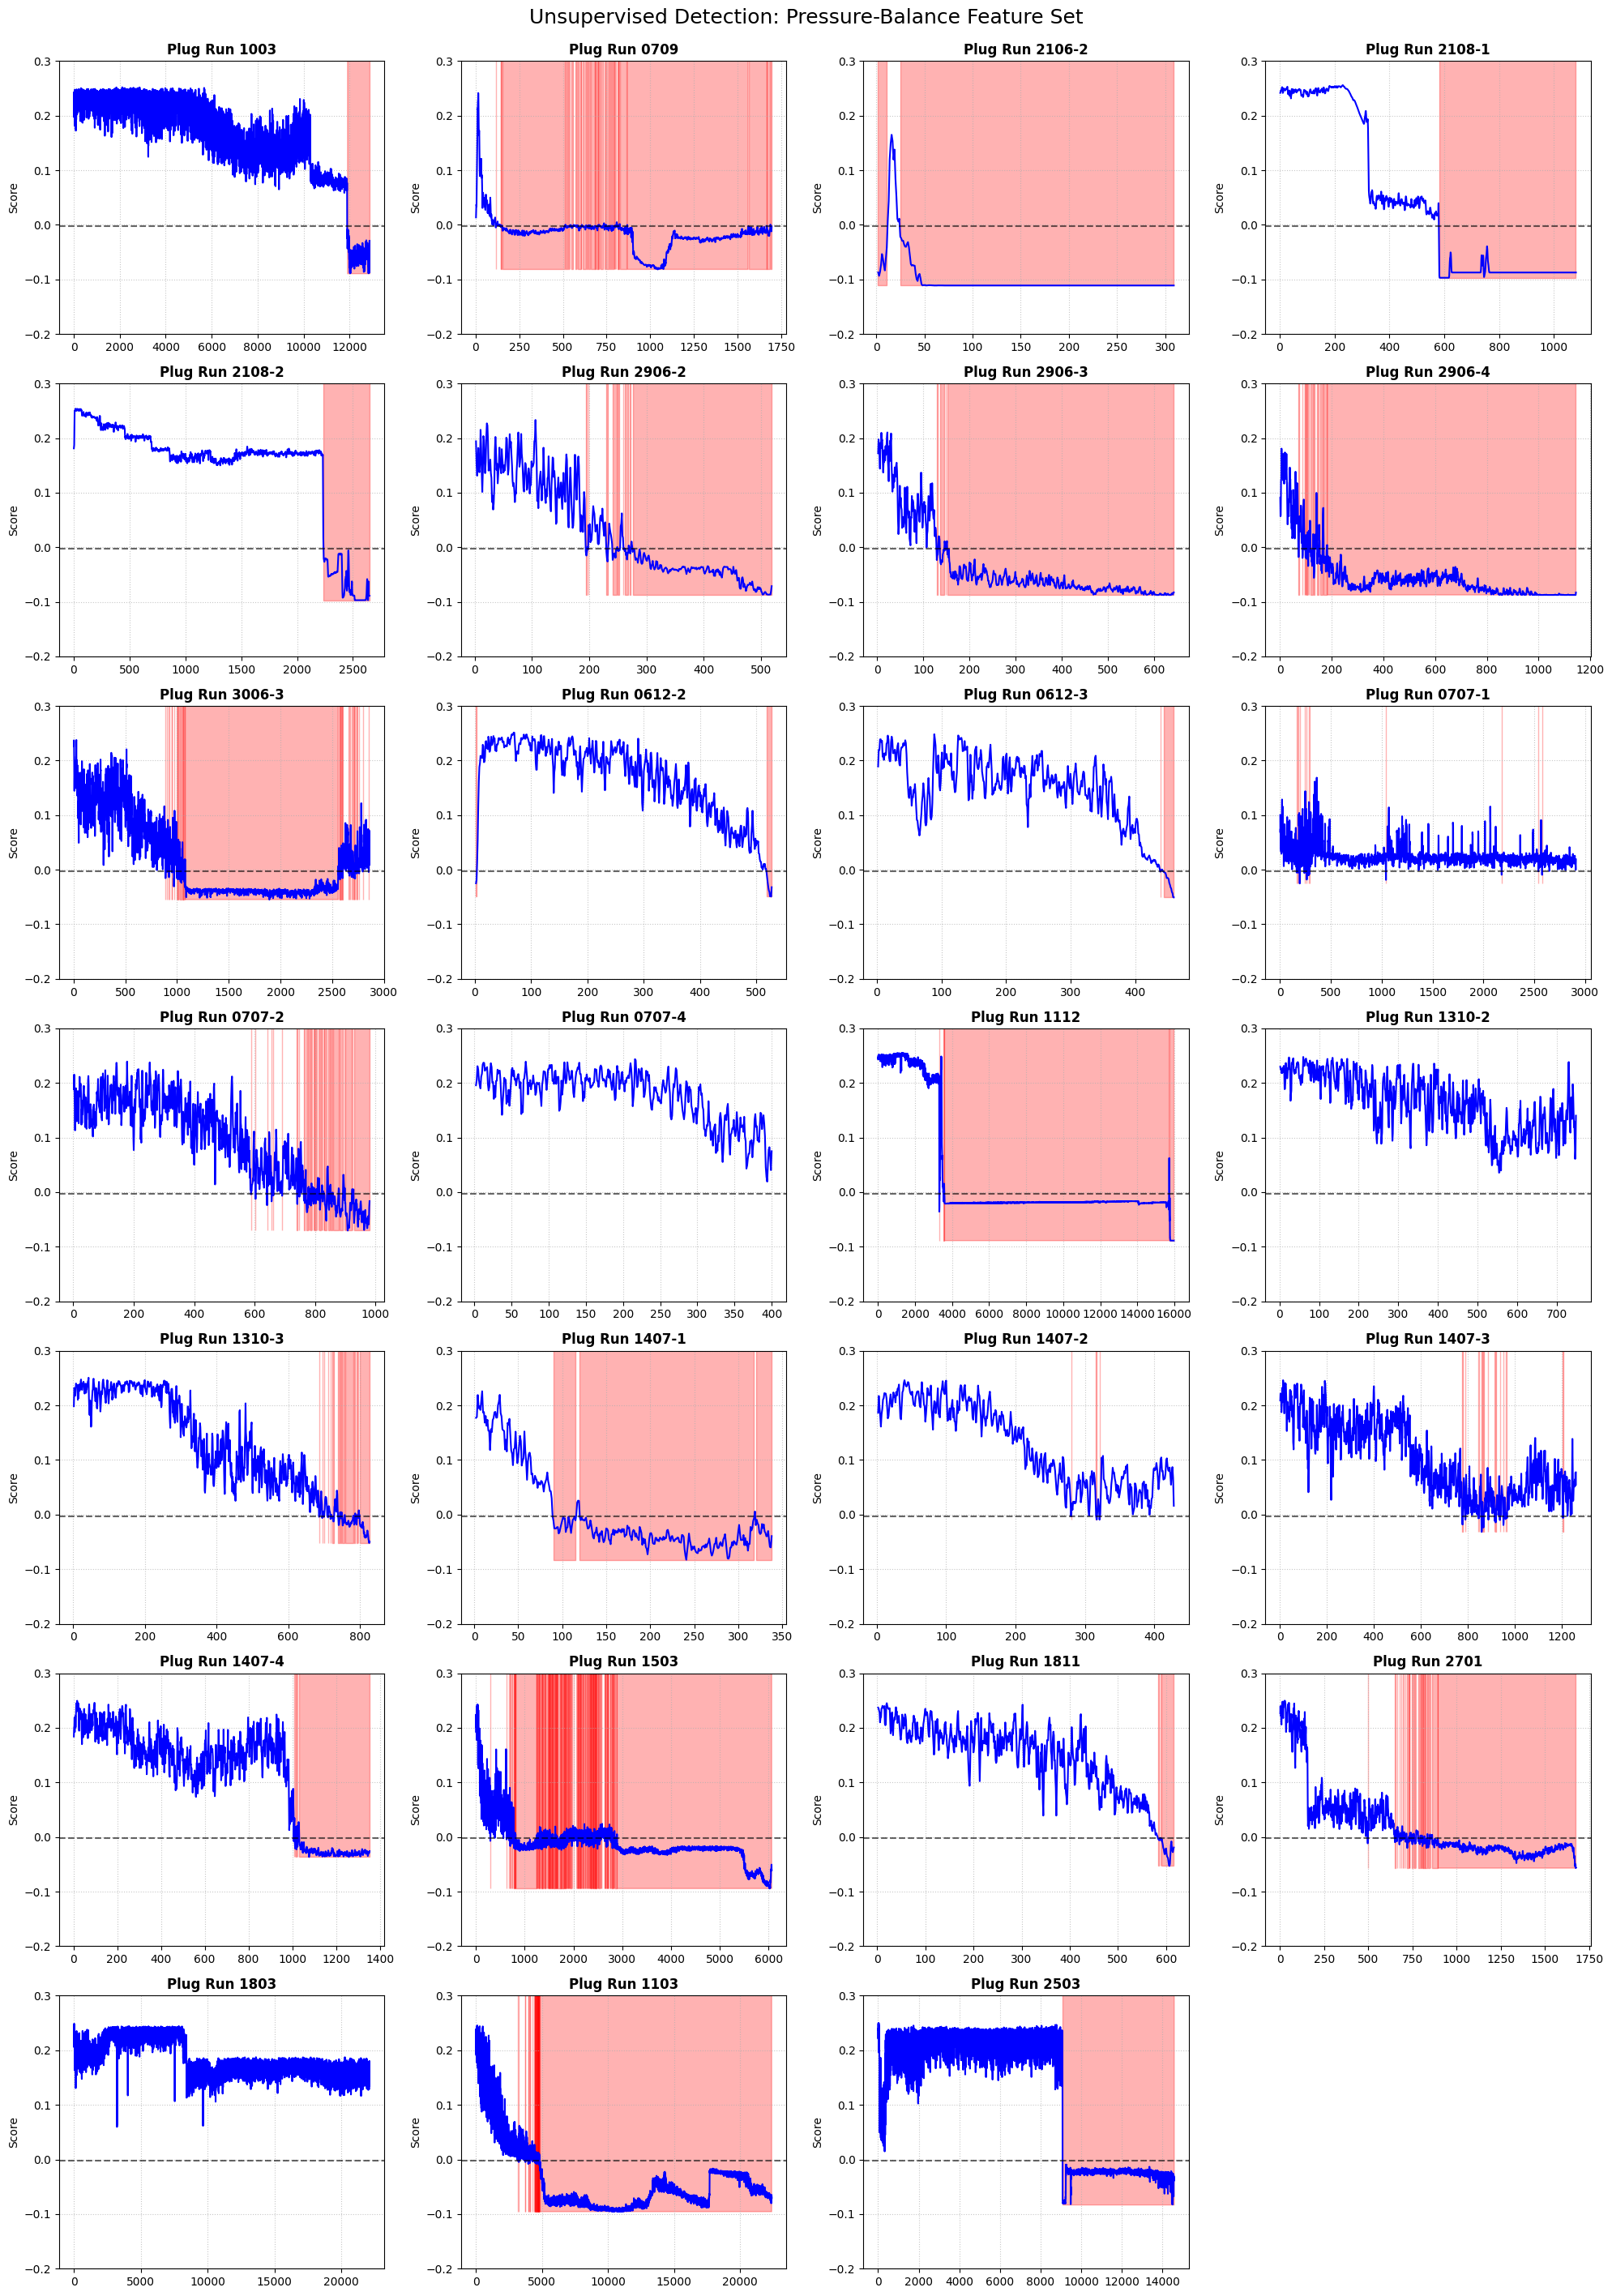

In [123]:
# 1. Configuration
threshold = -0.0025
cols = 4
rows = math.ceil(len(scored_plug_dfs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, df in enumerate(scored_plug_dfs):
    ax = axes[i]
    
    # Logic: 1 if anomaly, 0 if normal
    df['is_alert'] = (df['smooth_score'] < threshold).astype(int)
    
    # Plot the smoothed anomaly score
    ax.plot(df.index, df['smooth_score'], color='blue', linewidth=1.5, label='Anomaly Score')
    
    # Highlight the 'Alert' regions in red
    ax.fill_between(df.index, df['smooth_score'].min(), 0.5, 
                    where=df['is_alert']==1, color='red', alpha=0.3)
    
    # Threshold Line
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6)
    
    ax.set_title(f"Plug Run {p_names[i]}", fontweight='bold')
    ax.set_ylabel("Score")
    ax.set_ylim([-0.2, 0.3])
    ax.grid(True, linestyle=':', alpha=0.7)

# Cleanup unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f"Unsupervised Detection: Pressure-Balance Feature Set", fontsize=18, y=1.01)
plt.show()

PCA for featrure importance


Ting som kan tunes, window, contamination og estimator